# Analyse OCR predictions

Score EasyOCR / RapidOCR / PaddleOCR predictions against ground-truth fields,
aggregate to field recall and latency, write `eval/results/ocr_results.csv`, and data visualisation.

## 0. Setup

In [ ]:
# %pip install -q pandas matplotlib

In [88]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve repo root whether the kernel cwd is repo root or eval/analysis/
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "analysis":
    # Notebook opened from eval/analysis/
    REPO_ROOT = REPO_ROOT.parents[1]
elif (REPO_ROOT / "eval").is_dir():
    # Already at repo root
    pass
else:
    # Walk up until we find eval/predictions/
    for p in [REPO_ROOT, *REPO_ROOT.parents]:
        if (p / "eval" / "predictions").is_dir():
            REPO_ROOT = p
            break

# Define paths
GT_PATH = REPO_ROOT / "eval" / "datasets" / "ground_truths" / "ocr.jsonl"
PRED_DIR = REPO_ROOT / "eval" / "predictions"
RESULTS_DIR = REPO_ROOT / "eval" / "results"
RESULTS_CSV = RESULTS_DIR / "ocr_results.csv"

# Models to load from eval/predictions/{model}.jsonl
MODELS = ["easyocr", "rapidocr", "paddleocr"]

print("REPO_ROOT:", REPO_ROOT)
print("GT:", GT_PATH.exists(), GT_PATH)
print("PRED_DIR:", PRED_DIR)

REPO_ROOT: /Users/desmond/Documents/University/Y3/FP/imet
GT: True /Users/desmond/Documents/University/Y3/FP/imet/eval/datasets/ground_truths/ocr.jsonl
PRED_DIR: /Users/desmond/Documents/University/Y3/FP/imet/eval/predictions


## 1. Load

Read the prediction JSONLs, join ground truth on `id`, dump into one DataFrame.

In [ ]:
def load_jsonl(path: Path) -> list[dict]:
    """
    Load rows from a JSONL file then convert into a list of dictionaries.
    """
    rows: list[dict] = []

    # Read file line by line
    for line in path.read_text(encoding="utf-8").splitlines():
        # Skip empty lines
        if not line.strip():
            continue
        # Parse JSON and add to list
        rows.append(json.loads(line))

    return rows


# Step 1: Load ground truth and index by id for joining
gt_rows = load_jsonl(GT_PATH)
gt_by_id = {int(r["id"]): r["ground_truth"] for r in gt_rows}

# Step 2: Load each model's predictions and join GT on id
pred_rows: list[dict] = []
for model in MODELS:
    pred_path = PRED_DIR / f"{model}.jsonl"
    # Skip models that have not been run yet
    if not pred_path.is_file():
        print(f"missing: {pred_path}")
        continue

    # Build a list of dicts with the ground truth joined
    for row in load_jsonl(pred_path):
        row_id = int(row["id"])
        pred_rows.append({
            "model": row.get("model") or model,
            "id": row_id,
            "condition": row.get("condition"),
            "image": row.get("image"),
            "raw_text": row.get("raw_text") or "",
            "latency_ms": row.get("latency_ms"),
            "error": row.get("error"),
            "ground_truth": gt_by_id.get(row_id),
        })

# Step 3: Dump into one DataFrame (360 rows = 3 models x 120 images)
pred_df = pd.DataFrame(pred_rows)
print(pred_df.shape)
pred_df.head()

(360, 8)


,model,id,condition,image,raw_text,latency_ms,error,ground_truth
0,easyocr,1,raw,eval/datasets/images/raw/ocr_001.jpg,M\n+44207946 0812\nMargot Calder\nmargot@calde...,4147.10,None,"{'name': 'margot calder', 'roles': ['interior ..."
1,easyocr,2,raw,eval/datasets/images/raw/ocr_002.jpg,~Iwhoami\nnadia_kovac\ninfrastructure engineer...,3917.45,None,"{'name': 'nadia kovac', 'roles': ['infrastruct..."
2,easyocr,3,raw,eval/datasets/images/raw/ocr_003.jpg,OTTO\nBRANDT\nSTRUCTURAL FABRICATION\notto@bra...,4555.98,None,"{'name': 'otto brandt', 'roles': ['structural ..."
3,easyocr,4,raw,eval/datasets/images/raw/ocr_004.jpg,1\nHenrik Vestergaard\nNotary & Estates Counse...,3974.55,None,"{'name': 'henrik vestergaard', 'roles': ['nota..."
4,easyocr,5,raw,eval/datasets/images/raw/ocr_005.jpg,A T E L [ E R\nSEO YEON\nC R E ATIV E\nD | R E...,3880.54,None,"{'name': 'seo yeon', 'roles': ['creative direc..."


## 2. Score each row

For each GT field value
If it is found in `raw_text`, the `hit` becomes 1, otherwise 0

In [90]:
def norm_text(s: str) -> str:
    """
    Lowercase and collapse whitespace so OCR spacing quirks do not block a match.
    e.g. " John\n Smith " becomes "john smith"
    """
    return " ".join(s.lower().split())


def digits_only(s: str) -> str:
    """
    Keep digits only (used for phone matching across spaces, +, dashes).
    e.g. "+123 456-7890" becomes "1234567890"
    """
    return "".join(c for c in s if c.isdigit())


def found_in_ocr(field: str, value: str, raw_text: str) -> bool:
    """
    True if the GT value appears in OCR output after light normalisation.

    Phones: digit-only substring (handles spaces, +, dashes).
    Other fields: lowercased, collapsed-whitespace substring.
    Email also ignores spaces inside OCR text (EasyOCR sometimes drops dots/spaces).
    """
    # Skip empty OCR text
    if not raw_text:
        return False

    # Phone: compare digits only so formatting differences do not matter
    if field == "phone":
        gt_digits = digits_only(value)
        ocr_digits = digits_only(raw_text)
        return bool(gt_digits) and gt_digits in ocr_digits

    # Default: lowercased and collapsed whitespace substring match
    gt_norm = norm_text(value)
    ocr_norm = norm_text(raw_text)
    if not gt_norm:
        return False

    if gt_norm in ocr_norm:
        return True

    # Email: retry with all spaces removed
    if field == "email":
        return gt_norm.replace(" ", "") in ocr_norm.replace(" ", "")

    # No match
    return False

In [91]:
# Build a long table of per-field hits (one row per GT field value)
hit_rows: list[dict] = []

# Scalar GT keys (only contain string values)
SCALAR_FIELDS = ("name", "company", "email", "address", "social_handle")

# Iterate over each row in the DataFrame
for row in pred_df.itertuples(index=False):
    gt = row.ground_truth
    # Skip rows with missing GT
    if not isinstance(gt, dict):
        continue

    # Score scalar fields directly from the GT dict
    for field in SCALAR_FIELDS:
        value = (gt.get(field) or "").strip()
        if not value:
            continue
        hit_rows.append({
            "model": row.model,
            "id": row.id,
            "condition": row.condition,
            "field": field,
            "value": value,
            # 1 if field value was found in raw_text, else 0
            "hit": int(found_in_ocr(field, value, row.raw_text)),
            "latency_ms": row.latency_ms,
        })

    # Handle list fields (roles)
    for value in gt.get("roles") or []:
        value = (value or "").strip()
        if not value:
            continue
        hit_rows.append({
            "model": row.model,
            "id": row.id,
            "condition": row.condition,
            "field": "role",
            "value": value,
            "hit": int(found_in_ocr("role", value, row.raw_text)),
            "latency_ms": row.latency_ms,
        })

    # Handle list fields (phone)
    for value in gt.get("phone") or []:
        value = (value or "").strip()
        if not value:
            continue
        hit_rows.append({
            "model": row.model,
            "id": row.id,
            "condition": row.condition,
            "field": "phone",
            "value": value,
            "hit": int(found_in_ocr("phone", value, row.raw_text)),
            "latency_ms": row.latency_ms,
        })

hits_df = pd.DataFrame(hit_rows)
print(hits_df.shape)
hits_df.head(10)

(2028, 7)


,model,id,condition,field,value,hit,latency_ms
0,easyocr,1,raw,name,margot calder,1,4147.10
1,easyocr,1,raw,email,margot@calderstudio.co,0,4147.10
2,easyocr,1,raw,address,"12 bramley mews, london",1,4147.10
3,easyocr,1,raw,role,interior architect,1,4147.10
4,easyocr,1,raw,phone,442079460812,1,4147.10
5,easyocr,2,raw,name,nadia kovac,0,3917.45
6,easyocr,2,raw,email,nadia@kovac.sh,1,3917.45
7,easyocr,2,raw,role,infrastructure engineer,1,3917.45
8,easyocr,2,raw,phone,14155550142,1,3917.45
9,easyocr,3,raw,name,otto brandt,1,4555.98


## 3. Aggregate

- **Recall** = mean(`hit`) grouped by `model`, `condition`, `field`
- **Latency** = mean(`latency_ms`) grouped by `model`, `condition`

In [92]:
# Step 1: Field recall = mean hit within each (model, condition, field) group
recall = (
    hits_df.groupby(["model", "condition", "field"], as_index=False)
    .agg(n=("hit", "size"), hits=("hit", "sum"), recall=("hit", "mean"))
)

# Step 2: Average latency per model and condition.
latency = (
    hits_df.drop_duplicates(subset=["model", "id"])
    .groupby(["model", "condition"], as_index=False)
    .agg(latency_ms_mean=("latency_ms", "mean"))
)

# Step 3: Join recall and latency
results = recall.merge(latency, on=["model", "condition"], how="left")
results = results.sort_values(["model", "condition", "field"]).reset_index(drop=True)

# 84 rows (3 models × 4 conditions × 7 fields)
results.sample(10)

,model,condition,field,n,hits,recall,latency_ms_mean
51,paddleocr,warp_lowres,email,28,12,0.428571,1776.634333
35,paddleocr,raw,address,18,15,0.833333,5202.465667
1,easyocr,lowres,company,18,9,0.500000,698.753333
0,easyocr,lowres,address,18,1,0.055556,698.753333
54,paddleocr,warp_lowres,role,46,35,0.760870,1776.634333
7,easyocr,raw,address,18,9,0.500000,4274.465333
26,easyocr,warp_lowres,role,46,0,0.000000,689.685667
71,rapidocr,warp,company,18,10,0.555556,317.761667
5,easyocr,lowres,role,46,7,0.152174,698.753333
55,paddleocr,warp_lowres,social_handle,1,1,1.000000,1776.634333


## 4. Save

Overwrite `eval/results/ocr_results.csv`

In [93]:
# Ensure output directory exists for the results file
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Overwrite CSV
results.to_csv(RESULTS_CSV, index=False)
print(f"Wrote {len(results)} rows to {RESULTS_CSV.relative_to(REPO_ROOT)}")

Wrote 84 rows to eval/results/ocr_results.csv


## 5. Visualisation

1. Accuracy vs latency scatter
2. Degradation curve
3. OCR field recall by field
4. Full diagnostic heatmap

In [94]:
# Chart constants
MODEL_ORDER = ["easyocr", "rapidocr", "paddleocr"]
CONDITION_ORDER = ["raw", "lowres", "warp", "warp_lowres"]
HEATMAP_FIELDS = ["name", "role", "company", "email", "phone", "address"]

MARKERS = {
    "raw": "o",
    "lowres": "s",
    "warp": "^",
    "warp_lowres": "D",
}

# Average recall per model and condition
agg = (
    results.groupby(["model", "condition"], as_index=False)
    .agg(mean_recall=("recall", "mean"))
)

# Attach latency (one value per model and condition)
latency_dedup = (
    results.drop_duplicates(subset=["model", "condition"])
    [["model", "condition", "latency_ms_mean"]]
)
agg = agg.merge(latency_dedup, on=["model", "condition"], how="left")
agg["condition"] = pd.Categorical(
    agg["condition"], categories=CONDITION_ORDER, ordered=True
)
agg = agg.sort_values(["model", "condition"]).reset_index(drop=True)
agg

,model,condition,mean_recall,latency_ms_mean
0,easyocr,raw,0.783181,4274.465333
1,easyocr,lowres,0.221172,698.753333
2,easyocr,warp,0.682752,4533.410000
3,easyocr,warp_lowres,0.147959,689.685667
4,paddleocr,raw,0.924017,5202.465667
5,paddleocr,lowres,0.878300,1903.010667
6,paddleocr,warp,0.925195,5262.853333
7,paddleocr,warp_lowres,0.739648,1776.634333
8,rapidocr,raw,0.765089,328.621000
9,rapidocr,lowres,0.431031,201.818000


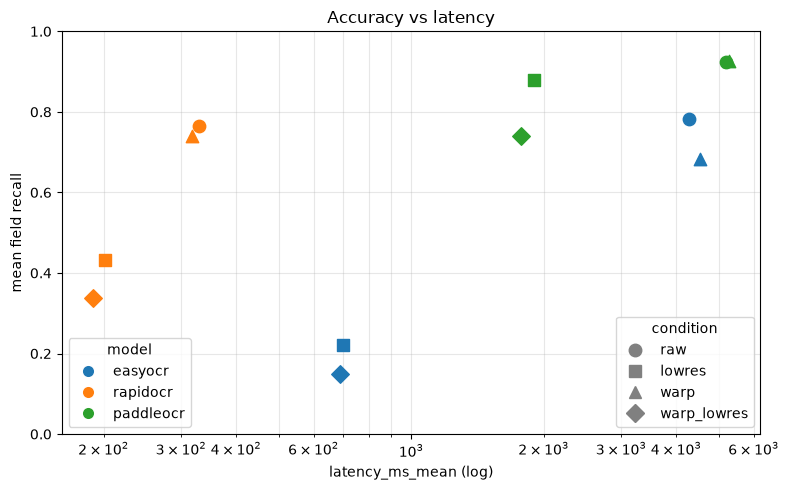

In [95]:
# 1. Accuracy vs latency scatter
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(8, 5))

for i, model in enumerate(MODEL_ORDER):
    m = agg[agg["model"] == model]
    for _, row in m.iterrows():
        ax.scatter(
            row["latency_ms_mean"],
            row["mean_recall"],
            color=f"C{i}",
            marker=MARKERS[row["condition"]],
            s=80,
            zorder=3,
            label="_nolegend_",
        )

# Legends: colour = model, shape = condition
model_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=f"C{i}", markersize=9, label=m)
    for i, m in enumerate(MODEL_ORDER)
]
cond_handles = [
    Line2D([0], [0], marker=MARKERS[c], color="gray", linestyle="None", markersize=9, label=c)
    for c in CONDITION_ORDER
]
leg1 = ax.legend(handles=model_handles, title="model", loc="lower left")
ax.add_artist(leg1)
ax.legend(handles=cond_handles, title="condition", loc="lower right")

ax.set_xscale("log")
ax.set_xlabel("latency_ms_mean (log)")
ax.set_ylabel("mean field recall")
ax.set_ylim(0, 1)
ax.set_title("Accuracy vs latency")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


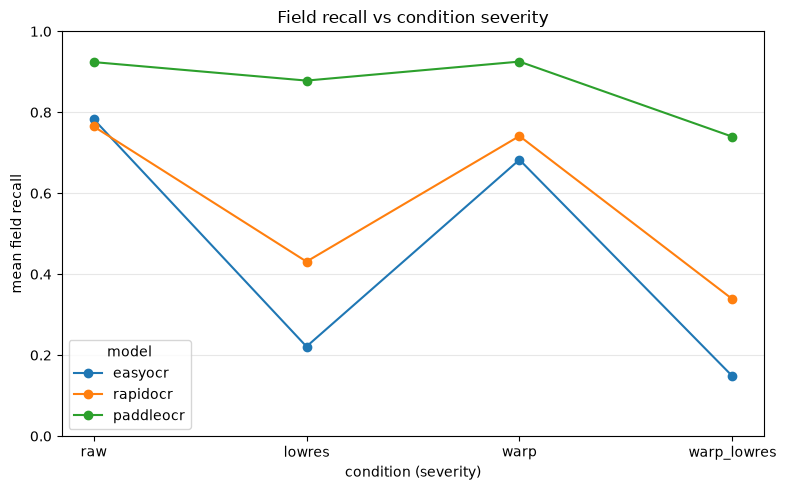

In [96]:
# 2. Degradation curve
fig, ax = plt.subplots(figsize=(8, 5))

for model in MODEL_ORDER:
    m = agg[agg["model"] == model].sort_values("condition")
    ax.plot(
        m["condition"].astype(str),
        m["mean_recall"],
        marker="o",
        label=model,
    )

ax.set_xlabel("condition (severity)")
ax.set_ylabel("mean field recall")
ax.set_ylim(0, 1)
ax.set_title("Field recall vs condition severity")
ax.legend(title="model")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


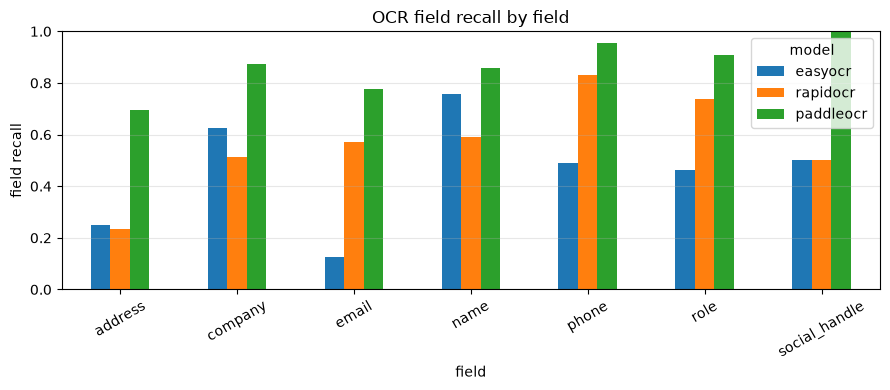

In [97]:
# 3. OCR field recall by field
# Pool hits/n across conditions so each bar is recall for that field
by_field = (
    results.groupby(["model", "field"], as_index=False)
    .agg(hits=("hits", "sum"), n=("n", "sum"))
)
by_field["recall"] = by_field["hits"] / by_field["n"]

# Pivot for grouped bars: rows = field, columns = model
pivot_recall_field = by_field.pivot(index="field", columns="model", values="recall")
pivot_recall_field = pivot_recall_field.reindex(columns=MODEL_ORDER)

ax = pivot_recall_field.plot(kind="bar", figsize=(9, 4), rot=30)
ax.set_ylabel("field recall")
ax.set_xlabel("field")
ax.set_title("OCR field recall by field")
ax.set_ylim(0, 1)
ax.legend(title="model")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


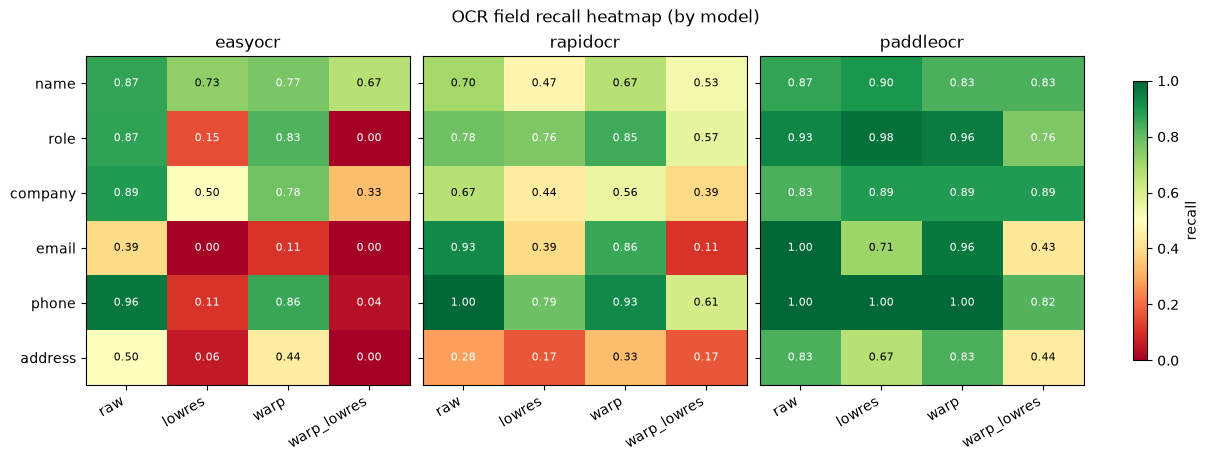

In [98]:
# 4. Full diagnostic heatmap (exclude social_handle)
heat = results[results["field"] != "social_handle"].copy()
heat["condition"] = pd.Categorical(
    heat["condition"], categories=CONDITION_ORDER, ordered=True
)
heat["field"] = pd.Categorical(heat["field"], categories=HEATMAP_FIELDS, ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5), sharey=True, layout="constrained")
cmap = plt.cm.RdYlGn
norm = plt.Normalize(vmin=0, vmax=1)

for ax, model in zip(axes, MODEL_ORDER):
    sub = heat[heat["model"] == model]
    pivot = sub.pivot(index="field", columns="condition", values="recall")
    pivot = pivot.reindex(index=HEATMAP_FIELDS, columns=CONDITION_ORDER)

    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, norm=norm)
    ax.set_xticks(range(len(CONDITION_ORDER)))
    ax.set_xticklabels(CONDITION_ORDER, rotation=30, ha="right")
    ax.set_yticks(range(len(HEATMAP_FIELDS)))
    ax.set_yticklabels(HEATMAP_FIELDS)
    ax.set_title(model)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if pd.isna(val):
                continue
            text_color = "black" if 0.3 < val < 0.75 else "white"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=8)

fig.colorbar(im, ax=axes, shrink=0.85, label="recall")
fig.suptitle("OCR field recall heatmap (by model)")
plt.show()
